## Clinical Data Engineering: Dataset Audit and Transformation in Valvular Heart Disease

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #fff5ef; color: #003152;">

**Project:** Quantifying Clinical Gaps in Valvular Heart Disease: Using the Medication Burden Index (MBI) to Triage High-Complexity Intervention Candidates.  
**Source:** Project Health for Leon, Phase 1 — 2025 General Cardiology Clinic ($N=187 \to 152$)  
**Key Transformation:** Gaussian "Natural Normal" Imputation  
**Version:** 1.1 (Post-Audit)  

---
**Technical Focus:** This notebook executes Extraction and Transformation for $N=152$ patients, specifically addressing **MNAR (Missing Not At Random)** bias through Natural Normal Imputation.  
**Key Metric:** Medication Burden Index (MBI)

</div>

### 🧠 The Clinical Knowledge Base (The "Medical Brain")
---

To ensure the reproducibility and clinical validity of this pipeline, we implemented a **Centralized Configuration Object** (config.py). In a real-world healthcare setting, separating clinical logic from processing code is vital—it allows medical directors to audit the criteria without needing to parse complex data engineering logic.

This class encapsulates:

* **Anatomic Groupings:** Organizing echo parameters by valve (Mitral vs. Aortic).

* **Pharmacological Mapping:** Cataloging max doses and clinical weights for the Medication Burden Index (MBI).

* **Heuristic Logic:** Regex patterns for extracting diagnoses from messy clinical notes.

* **Physiological Baselines:** Defining the $\mu$ and $\sigma$ for the Natural Normal Imputation.

In [183]:
# 1. IMPORTS
# ==========================================

import pandas as pd
import numpy as np
from IPython.display import display, Markdown, HTML
import re
import missingno as msno
import matplotlib.colors as mcolors
import statsmodels.api as sm
from sklearn.metrics import roc_curve, auc, f1_score, precision_score, recall_score, confusion_matrix
from scipy.stats import kruskal, chi2_contingency
import scipy.stats as sstats
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path


sys.path.append(str(Path.cwd().parent))
from config import ClinicalConfig # The new 'Medical Brain' source

### 🔎 Quality Control (The Auditor)
---

**Establishing Clinical Accountability**


Before any analysis, we must validate the "integrity" of our dataset. In a medical brigade context, traditional data cleaning (like dropping rows with nulls) would result in losing 80% of our most important cases.

In [184]:
# 2. AUDITOR CLASS
# ==========================================

class Auditor:
    """
    Acts as the 'Quality Control' station. 
    Before any analysis, we must check the integrity of our dataset.
    """
    def __init__(self, dataframe, config):
        self.df = dataframe
        self.config = config

    def report(self):
        """
        Generates a 3-part audit: 
        1. Technical metadata.
        2. Clinical category missingness (shows which exam parts were skipped).
        3. Lexicon extraction (identifies unique raw strings for manual review).
        """
        audit = []
        for col in self.df.columns:
            audit.append({
                'Column': col,
                'Inferred dtype': self.df[col].dtype,
                'Null Count': self.df[col].isnull().sum(),
                'Sample Values': self.df[col].dropna().unique()[:3].tolist()
            })
            
        # Clinical NLP: Extracting the vocabulary used by doctors in the field.
        all_diagnoses = pd.concat([
            self.df['Pre-procedure diagnosis'],
            self.df['Post-procedure diagnosis']
        ]).str.split(',').explode().str.strip().dropna().unique()

        all_medications = self.df['Medications'].str.split('|').explode().str.strip().dropna()
        medications_unique = all_medications.str.split(' ').str[0].str.capitalize().unique()

        # Report Missingness by Clinical Grouping
        print(f"Current columns by category:\n{'-'*40}")
        for category, cols in self.config.categories.items():
            print(f"{category}: {cols}")

        group_report = {}
        missing_from_categories = []

        for group, cols in self.config.categories.items():
            # Checks if our expected columns actually exist in the CSV header
            not_found = [c for c in cols if c not in self.df.columns]
            found = [c for c in cols if c in self.df.columns]

            # Log dictionary columns missing in the dataset
            if not_found:
                missing_from_categories.extend(not_found)
                print(f"\nWarning in {group}: Missing from CSV: {not_found}")
                
            # Calculates mean missingness for columns existing in the dataset
            if found:
                avg_miss = self.df[found].isnull().mean().mean() * 100
                group_report[group] = f"{avg_miss:.2f}% missing"
            else:
                group_report[group] = "N/A - No columns found"

        print("\nMean missingness by category (%):")
        print(f"{'-'*40}")
        print(pd.Series(group_report))

        # Persistence: Ensuring we have an 'Audit Trail' for clinical accountability.
        audit_df = pd.DataFrame(audit)
        pd.DataFrame({'All_diagnoses_list': all_diagnoses}).to_csv(r'..\data\processed\all_diagnoses_report.csv', index=False)
        pd.DataFrame({'All_medications_list': medications_unique}).to_csv(r'..\data\processed\all_medications_report.csv', index=False)
        audit_df.to_csv(r'..\data\processed\dataset_audit_report.csv', index=False)

        print('\nAudit report generated:\n' + f"{'-'*40}")
        print('Technical metadata file generated')
        print('All unique diagnoses list generated')
        print('All medications list generated')
        print('Check generated files at data/processed')
        return audit_df
        
    def echo_missingness(self):
        """
        Forensic Data Audit: 
        Calculates completion rates (%) per column, stratified by 
        disease severity and clinical grouping.
        """
        results = []
        
        # Access the injected echo_groups_dict
        for unit, groups in self.config.echo_groups.items():
            for sev_col in groups["Severity_Cols"]: 
                if sev_col not in self.df.columns:
                    continue
                
                for sev_level in sorted(self.df[sev_col].unique()):
                    subset = self.df[self.df[sev_col] == sev_level]
                    if subset.empty: continue
                    
                    for param in groups["Parameters"]:
                        if param in self.df.columns:
                            completeness = (1 - subset[param].isnull().mean()) * 100
                            results.append({
                                'Pathology': sev_col.replace('Sev_', ''),
                                'Severity': sev_level,
                                'Parameter': param,
                                'Completeness_Pct': round(completeness, 2),
                                'N': len(subset)
                            })
                            
        missings_stratified = pd.DataFrame(results)

        # Pivot for 'Missingness Matrix' visualization. 
        pivot_audit = missings_stratified.pivot_table(
            index=['Pathology', 'Parameter'], 
            columns='Severity', 
            values='Completeness_Pct' 
        )
        return pivot_audit

In [185]:
# 3. EXTRACTOR CLASS
# ==========================================

class Extractor:
    """
    The 'Refinery'. Transforms messy clinical strings into clean, structured data,
    preserving mixed valvular disease signatures.
    """
    def __init__(self, dataframe, config):
        self.df = dataframe
        self.config = config
        self.severities = list(self.config.severity.keys())
        # Regex to strip intensity
        self.strip_pattern = r'\b(' + '|'.join(self.severities) + r')\b'

    def _get_expanded_diag(self, col_name):
        """
        Handles comma-separated lists in a single cell.
        """
        return self.df[col_name].str.lower().str.split(',').explode().str.strip().dropna()

    def _clean_column(self, col):
        """
        Standardizes anatomy by removing qualitative noise and surgical terms.
        """
        s = self._get_expanded_diag(col)
        cleaned = s.str.replace(self.strip_pattern, '', regex=True) \
            .str.replace(r'\s+', ' ', regex=True) \
            .str.strip() \
            .str.capitalize()
        
        # Group back to original rows to maintain 1:1 patient mapping.
        return cleaned.groupby(level=0).agg(lambda x: ', '.join(x.unique()) if x.any() else np.nan)

    def _parse_meds(self, med_string, drug_list):
        """
        Pharmacological Parser:
        Identifies drug, extracts base dose, and applies frequency multipliers (e.g., bid=x2).
        """
        if pd.isna(med_string) or med_string == "":
            return "None", 0.0
            
        individual_meds = [m.strip().lower() for m in str(med_string).split('|')]
        
        for med_entry in individual_meds:
            matched_drug = next((d for d in drug_list if d.lower() in med_entry), None)
            
            if matched_drug:
                # Searches for match medications
                dose_match = re.search(r'(\d+\.?\d*)', med_entry)
                # Normalizes the medication intensity based on the max recommended dose
                base_dose = float(dose_match.group(1)) if dose_match else 0.0
                
                # Determine frequency multiplier
                multiplier = 1 
                for freq, value in self.config.freq_day.items():
                    if f" {freq}" in f" {med_entry}":
                        multiplier = value
                        break
                
                return matched_drug.capitalize(), base_dose * multiplier
                
        return "None", 0.0

    def transform(self):
        """
        Creates a multidimensional lesion matrix (e.g., separate columns for MS and MR severity).
        """
        # 1. Anatomy Extraction (The 'What' is involved)
        self.df['Anatomy_Pre'] = self._clean_column('Pre-procedure diagnosis')
        self.df['Anatomy_Post'] = self._clean_column('Post-procedure diagnosis')

        # 2. Multidimensional Severity Mapping (The 'How Bad' is it?)
        def severity_score(text_series, path_regex):
            entries = str(text_series).lower().split(',')
            for entry in entries:
                if re.search(path_regex, entry):
                    for label, score in self.config.severity.items():
                        if label in entry: return score
            return 0.0

        # 3. Normalize the severities per most relevant diagnoses
        for lesion, keywords in self.config.pathology_patterns.items():
            col_name = f'Sev_{lesion}'
            pattern = '|'.join(keywords) 
            self.df[col_name] = self.df['Pre-procedure diagnosis'].fillna('').apply(
                lambda x: severity_score(x, pattern)
            )

        # 4. Procedural Classification (The 'Approach')
        self.df['Approach'] = 'Native'
        post_exploded = self._get_expanded_diag('Post-procedure diagnosis')
        
        for group, keywords in self.config.procedures.items():
            pattern = '|'.join(keywords)
            idx = post_exploded[post_exploded.str.contains(pattern, regex=True, na=False)].index
            self.df.loc[idx, 'Approach'] = group

        # 5. Pharmacological Quantification
        for category, drugs in self.config.medication_classes.items():
            name_col = f"{category}_name"
            dose_col = f"{category}_tdd"
            
            # Use the internal _parse_meds method with injected freq_day
            self.df[[name_col, dose_col]] = self.df['Medications'].apply(
                lambda x: pd.Series(self._parse_meds(x, drugs))
            )

        # 6. Left Atrium Size Scoring
        self.df['LA_Size_Score'] = 0.0
        self.df['LA_Thrombus'] = 0.0
        self.df['LA_Mass'] = 0.0
        
        for score, pattern in self.config.la_patterns.items():
            # Only update if current score is lower (preserves the highest severity found)
            mask = self.df['Left atrium'].str.contains(pattern, case=False, na=False, regex=True)
            self.df.loc[mask, 'LA_Size_Score'] = np.maximum(self.df.loc[mask, 'LA_Size_Score'], score)

        # 7. Pathological Findings (Flags)
        # Thrombus/Clot/Smoke
        self.df['LA_Thrombus'] = self.df['Left atrium'].str.contains(r'(?:thrombus)', case=False, na=False, regex=True).astype(int)

        # Masses (Myxomas)
        self.df['LA_Mass'] = self.df['Left atrium'].str.contains(r'(?:myxoma)', case=False, na=False, regex=True).astype(int)
        
        # 8. Normalization of echo 
        for col in self.config.echo_missing:
            if col in self.df.columns:
                # Convert to string and handle whitespace
                # Use of .str.strip() catches hidden spaces like " 25 "
                s = self.df[col].astype(str).str.lower().str.strip()
                
                # Replace qualitative terms (trace, mild) with the values at the dictionary
                s = s.replace(self.config.echo_severity)
                
                # Final Coercion
                # If a value was "45mm", pd.to_numeric turns it to NaN. 
                # If the data has "mm" in it, strip it first.
                s = s.str.extract(r'(\d+\.?\d*)')[0] # Remove all non-numeric chars
                
                self.df[col] = pd.to_numeric(s, errors='coerce').round(1)

        # 9. LVEF Numerical Mapping
        # Use of .str.title() to match 'Normal', 'Reduced', etc. 
        if 'LVEF (categorical)' in self.df.columns:
            self.df['LVEF_Score'] = self.df['LVEF (categorical)'].str.strip().str.title().map(self.config.lvef_values)
            
            # Clinical Safety Check: If "Moderately reduced" has a lowercase 'r', 
            # title() makes it "Moderately Reduced". Adjust by the map or use a lambda.
            self.df['LVEF_Score'] = self.df['LVEF (categorical)'].str.strip().map(
                {k: v for k, v in self.config.lvef_values.items()} # Direct map
            ).fillna(self.df['LVEF (categorical)'].str.strip().str.capitalize().map(self.config.lvef_values))
            
        return self.df

    def baseline(self):
        """
        Generate a Table of demographics and vitals.
        Calculate Mean ± SD for continuous and N (%) for categorical.
        """
        stats = []
        vitals = self.config.categories.get("Demographics/Vitals", [])

        print("Baseline characteristics\n" + '-'*40)

        for col in vitals:
            if col in self.df.columns:
                # Handles numeric columns (Age, Weight, Vitals)
                if pd.api.types.is_numeric_dtype(self.df[col]):
                    mean_val = self.df[col].mean()
                    std_val = self.df[col].std()
                    null_pct = self.df[col].isnull().mean() * 100
                    stats.append({
                        "Characteristic": col,
                        "Value": f"{mean_val:.1f} ± {std_val:.1f}",
                        "Completeness": f"{100 - null_pct:.1f}%",
                        "Type": "Continuous"
                    })
                # Handles categorical (Gender)
                else:
                    top_val = self.df[col].mode()[0] if not self.df[col].mode().empty else "N/A"
                    count = (self.df[col] == top_val).sum()
                    pct = (count / len(self.df)) * 100
                    stats.append({
                        "Characteristic": col,
                        "Value": f"Mode: {top_val} ({pct:.1f}%)",
                        "Completeness": f"{100 - (self.df[col].isnull().mean()*100):.1f}%",
                        "Type": "Categorical"
                    })
                
        return display(pd.DataFrame(stats).set_index("Characteristic"))

    def diagnoses_prevalence(self):
        """
        Standardize and count the global disease burden in the cohort.
        """
        # Note: transform() must be called before this method to generate Anatomy_Pre
        if 'Anatomy_Pre' not in self.df.columns:
             raise ValueError("Please run transform() first.")
        
        pre = self.df['Anatomy_Pre'].str.split(', ').explode()
        post = self.df['Anatomy_Post'].str.split(', ').explode()
        
        # Combine them and remove 'nan' strings or empty entries
        combined = pd.concat([pre, post])
        combined = combined[~combined.isin(['nan', '', 'None', 'None, None'])]
        
        # Calculate Counts
        counts = combined.value_counts()
        
        # Create the final Table
        prevalence_df = pd.DataFrame({
            'Patient Count': counts,
            'Prevalence (%)': (counts / len(self.df) * 100).round(1)
        })
        
        prevalence_df.index.name = 'Diagnosis'

        return prevalence_df

    def disease_profiler(self):
        '''
        Identify complex interactions: Mixed Lesions, Shunts, and Rhythm Confounders.
        '''
        if 'Sev_MS' not in self.df.columns:
             raise ValueError("Please run transform() with required dictionaries before running disease_profiler()")

        # 1. Mixed Valvular Disease (Same-valve: Stenosis + Regurgitation)
        self.df['Mixed_Mitral'] = ((self.df['Sev_MS'] > 0) & (self.df['Sev_MR'] > 0)).astype(int)
        self.df['Mixed_Aortic'] = ((self.df['Sev_AS'] > 0) & (self.df['Sev_AR'] > 0)).astype(int)

        # 2. Multi-Valvular Disease (Cross-valve: Mitral unit AND Aortic unit)
        mitral_any = (self.df['Sev_MS'] > 0) | (self.df['Sev_MR'] > 0)
        aortic_any = (self.df['Sev_AS'] > 0) | (self.df['Sev_AR'] > 0)
        self.df['Multi_Valve'] = (mitral_any & aortic_any).astype(int)

        # 3. Pulmonary Hypertension
        # Defined here as any PH mention (Severity > 0)
        self.df['PH_Present'] = (self.df['Sev_PH'] > 0).astype(int)
        self.df['PH_Significant'] = (self.df['Sev_PH'] >= 2.0).astype(int)

        # 4. Septal Defects
        shunt_pattern = '|'.join(self.config.pathology_patterns['Septal'])
        self.df['Has_Shunt'] = self.df['Pre-procedure diagnosis'].str.contains(
            shunt_pattern, case=False, na=False, regex=True
        ).astype(int)

        # 5. Rhythm Confounders (AFib)
        self.df['AFib_Present'] = self.df['Pre-procedure diagnosis'].str.contains(
            'Atrial fibrillation', case=False, na=False, regex=True
        ).astype(int)

        # 6. Global Complexity Score 
        # Summing binary flags. Note: For PH, we only count it as a single 'Complexity Point' 
        # if it is Moderate or worse (>= 2.0), as Mild PH is very common.
        self.df['Complexity_Score'] = (
            self.df['Mixed_Mitral'] + 
            self.df['Mixed_Aortic'] + 
            self.df['Multi_Valve'] + 
            self.df['AFib_Present'] + 
            self.df['PH_Significant']
        )

        # Accurate Prevalence Reporting
        self.complexity_stats = {
            "Total Patients": len(self.df),
            "Mixed Mitral": self.df['Mixed_Mitral'].sum(),
            "Mixed Aortic": self.df['Mixed_Aortic'].sum(),
            "Multi-Valvular": self.df['Multi_Valve'].sum(),
            "Significant PH (>=2.0)": self.df['PH_Significant'].sum(),
            "AFib Present": self.df['AFib_Present'].sum()
        }
        
        return self.df
        
    def complexity_report(self):
        """
        Returns the stats as a clean Pandas Series for easy display or export.
        """
        print("Complex cases\n" + '-'*40)
        print("Cases that have either mixed, multiple valvular disease and/or other conditions\n")
        if hasattr(self, 'complexity_stats'):
            return pd.Series(self.complexity_stats, name="Prevalence")
        else:
            return "Profiler has not been run yet."

In [186]:
# 4. CALCULATOR CLASS
# ==========================================

class Calculator:
    def __init__(self, dataframe, config):
        self.df = dataframe
        self.config = config

    def medication_index(self):
        """
        Compute the Medication Burden Index (MBI).
        MBI = Sum(Class_Weight * (Actual_TDD / Max_TDD))
        """
        self.df['MBI'] = 0.0
        
        for category, weight in self.config.class_weights.items():
            name_col = f"{category}_name"
            dose_col = f"{category}_tdd"
            
            if name_col in self.df.columns:
                # Vectorized calculation for each class
                # Uses 1.0 as a fallback intensity for fixed-dose meds (like Aspirin)
                intensity = self.df.apply(
                    lambda x: x[dose_col] / self.config.max_doses.get(x[name_col], x[dose_col]) 
                    if x[dose_col] > 0 else 0, axis=1
                )
                
                # Clips intensity at 1.0 (to avoid outliers from rare supra-therapeutic doses)
                self.df['MBI'] += (intensity.clip(upper=1.0) * weight)
                
        return self.df

In [187]:
# 6. STATISTICS CLASS
# ==========================================
class Statistics:
    def __init__(self, dataframe, config):
        self.df = dataframe
        self.config = config

    def impute_normal(self, target_col):
        """
        Implements 'Brigade Logic': Missing values are assumed normal, 
        but filled with Gaussian noise to preserve dataset variance.
        """
        temp_df = self.df.copy()
        temp_df[target_col] = pd.to_numeric(temp_df[target_col], errors='coerce')
        
        mask = temp_df[target_col].isnull()
        num_missing = mask.sum()
        
        mean, std = self.config.normal_variables.get(target_col, (0, 1))
        simulated_normals = np.random.normal(mean, std, size=num_missing).round(1)
        temp_df.loc[mask, target_col] = np.clip(simulated_normals, 0, 150)
                
        return temp_df[target_col]

    def apply_imputation(self):
        for var in self.config.echo_missing:
            if var in self.df.columns:
                # Use 'Natural Normal' to respect Brigade Logic while keeping variance
                self.df[f'{var}_Imputed'] = self.impute_normal(var)
                print(f"Handled {var} using 'Natural Normal' distribution.")

        return self.df
    
    def sensitivity_report(self):
        """
        Create a succinct summary comparing Measured (Sick) vs. Imputed (Cohort) data.
        """
        summary_data = []
        
        # Look at variables that were actually imputed
        for var in self.config.echo_missing:
            imp_col = f"{var}_Imputed"
            
            if var in self.df.columns and imp_col in self.df.columns:
                # Data for patients who actually had measurements
                measured = self.df[var].dropna()
                
                # Data for the whole cohort after imputation
                cohort = self.df[imp_col]
                
                if len(measured) > 0:
                    m_mean = measured.mean()
                    c_mean = cohort.mean()
                    delta = c_mean - m_mean
                    
                    # Clinical Interpretation Logic
                    # If the shift is more than 10% of the measured value, we flag it.
                    bias_status = "Significant Shift" if abs(delta) > (m_mean * 0.1) else "Stable"
                    
                    summary_data.append({
                        "Clinical Parameter": var,
                        "Measured Mean": round(m_mean, 1),
                        "Imputed Mean": round(c_mean, 1),
                        "Delta (Shift)": round(delta, 1),
                        "Triage Bias": bias_status
                        })

        # Create DataFrame
        report_df = pd.DataFrame(summary_data).set_index("Clinical Parameter")
        return report_df

In [188]:
# 6. VISUALIZER CLASS
# ==========================================
class Visualizer:
    def __init__(self, dataframe, config):
        self.df = dataframe
        self.config = config
        plt.style.use('seaborn-v0_8-white') 
        sns.set_context("paper", font_scale=1.2)
        plt.rcParams['font.family'] = 'sans-serif' # JACC prefers clean sans-serif

    def patient_nullity(self):
        # Forensic Audit: Visualizing data deserts to evaluate mission-specific documentation constraints.
        available_keys = [v for v in self.config.echo_vars if v in self.df.columns]

        print("Missingness visualizations\n" + '-' *40)
        with plt.style.context('default'):
            plt.figure(figsize=(10, 6))
            msno.matrix(self.df[available_keys], 
                        sparkline=False, 
                        color=mcolors.to_rgb('#2c3e50'), # Your dark blue
                        fontsize=10)
            plt.title("Nullity Matrix: Data Presence (Dark) vs Missing (White)", fontsize=14)
            plt.show()

        print("Note: Correlation of Missingness (1.0 = Always missing together):")
        with plt.style.context('default'):
            msno.heatmap(self.df[available_keys], cmap='Blues')
            plt.title("Missingness Correlation")
            plt.show()

    def echo_matrix(self, table):
        # Triage Efficiency: Quantifying which physiological parameters are deemed 'Critical Path' by the field team.
        print("\nEchocardiogram Triage Matrix notes:" + "\n" + "-"*40)
        print("A 'Hot' cell (High %) indicates a parameter the cardiologist deemed mandatory for triage.")
        
        plt.figure(figsize=(14, 10))
        # Use of a sequential colormap to highlight 'Data Deserts' vs 'Data Oases'.
        sns.heatmap(table.fillna(0), annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': 'Completeness %'})
        plt.title("Echocardiogram Triage Matrix: Data Presence as a Function of Disease Severity", fontsize=15)
        plt.xlabel("Clinician-Assessed Severity (Ordinal Scale)")
        plt.ylabel("Echocardiographic Parameter by Pathology")
        plt.show()

    def complexity_frequency(self):
        """
        Visualize the phenotypic burden of the cohort.
        """
        plt.figure(figsize=(10, 6))
        
        # Count frequencies of each score
        counts = self.df['Complexity_Score'].value_counts().sort_index()
        
        # Create a bar plot
        sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="GnBu", legend=False)
        
        plt.title("Distribution of Patient Complexity Scores", fontsize=15)
        plt.xlabel("Complexity Score (0 = Simple, 1+ = Highly Complex)", fontsize=12)
        plt.ylabel("Number of Patients", fontsize=12)
        
        # Add labels on top of bars
        for i, val in enumerate(counts.values):
            plt.text(i, val + 0.5, str(val), ha='center', fontsize=11, fontweight='bold')
            
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

    def complexity_markers(self):
        """
        Show the prevalence of specific complexity markers.
        """
        prevalence = self.df[self.config.clinical_markers].sum().sort_values(ascending=False)
        
        plt.figure(figsize=(10, 6))
        prevalence.plot(kind='barh', color='#2c3e50')
        plt.title("Prevalence of Complexity Markers", fontsize=15)
        plt.xlabel("Patient Count", fontsize=12)
        plt.gca().invert_yaxis()
        plt.show()

    def complexity_heatmap(self):
        """
        Interaction Analysis: Identifying 'Syndromic Clusters' where multiple pathologies co-exist, 
        increasing clinical risk.
        """
        # Calculate the correlation (co-occurrence)
        # We use 'pearson' here to see how strongly one predicts the other
        interaction_matrix = self.df[self.config.clinical_markers].corr()

        plt.figure(figsize=(10, 8))
        sns.heatmap(interaction_matrix, annot=True, cmap='GnBu', center=0, fmt=".2f")
        
        plt.title("Clinical Interaction Heatmap: Pathological Clustering", fontsize=15)
        plt.tight_layout()
        plt.show()

    def sensitivity_grid(self):
        """
        Generate a 2x2 matrix of KDE plots comparing Measured vs. Imputed data.
        """
        # Identify variables to plot
        plot_vars = [v for v in self.config.echo_missing if v in self.df.columns]
        
        # Create the 2x2 figure (4 subplots)
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.flatten()

        for i, var in enumerate(plot_vars):
            if i >= 4: break # Limit to 4x4 grid
            
            ax = axes[i]
            imp_col = f"{var}_Imputed"
            
            if imp_col in self.df.columns:
                # Measured Data (The "Sick" Triage Group)
                sns.kdeplot(self.df[var].dropna(), ax=ax, color='#08519c', fill=True, 
                            label='Measured', alpha=0.3)
                
                # Total Cohort (The "Natural Normal" Imputation)
                sns.kdeplot(self.df[imp_col], ax=ax, color='#969696', linestyle='--', 
                            label='Total Cohort')
                
                ax.set_title(f"{var}: Distribution Shift", fontsize=12, fontweight='bold')
                ax.set_xlabel("Value")
                ax.set_ylabel("Density")
                ax.legend(fontsize=8)
            else:
                ax.text(0.5, 0.5, f"No Data for {var}", ha='center')

        # Clean up empty subplots if fewer than 4 variables exist
        for j in range(len(plot_vars), 4):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.suptitle("Clinical Sensitivity Matrix: Measured vs. Imputed Populations", 
                    fontsize=14, y=1.02)
        plt.show()

    def validate_vis(self, matrix, x_label, y_label, title):
        # Generate confusion matrix
        plt.figure(figsize=(8,6))
        sns.heatmap(matrix, annot=True, fmt='d', cmap='GnBu', 
                    xticklabels=['MBI Low', 'MBI High'], 
                    yticklabels=['Healthy', 'Complex'])
        plt.xlabel(x_label)
        plt.ylabel(y_label)
        plt.title(title)
        print("\nConfusion matrix visualization\n" + '-'*40)
        plt.show()

In [189]:
# 7. EXECUTION
# ==========================================
# Setup
config = ClinicalConfig()

# Load
path = r'..\data\raw\phl_2025.csv'
if not os.path.exists(path):
    print(f"CRITICAL ERROR: File not found at {os.path.abspath(path)}")
else:
    load = pd.read_csv(path, dtype={'ID': str})
    print(f"Successfully loaded {len(load)} patient records.")
all_cols = [col for sublist in config.categories.values() for col in sublist]
df = load[load.columns.intersection(all_cols)].copy()

print("\nCurrent columns in the dataset")
print(df.columns)

# Instantiate classes
auditor = Auditor(df, config)
extractor = Extractor(df, config)
stats = Statistics(df, config)
calc = Calculator(df, config)
viz = Visualizer(df, config)

Successfully loaded 152 patient records.

Current columns in the dataset
Index(['ID', 'Age', 'Gender', 'Pre-procedure diagnosis',
       'Post-procedure diagnosis', 'Year(s) since procedure', 'Medications',
       'SBP R', 'DBP R', 'Heart rate', 'OSat', 'Weight', 'IVSd', 'LVIDd',
       'LVPWd', 'LVIDs', 'Aortic root', 'Left atrium measure', 'Left atrium',
       'LVEF (categorical)', 'AO V1 max', 'AO V2 max', 'MS MG (mmHg)',
       'TR Vmax', 'RVSP'],
      dtype='str')


In [190]:
# Baseline Integrity Audit
# ==========================================
audit_report = auditor.report()

Current columns by category:
----------------------------------------
Demographics/Vitals: ['ID', 'Age', 'Gender', 'Weight', 'OSat', 'SBP R', 'DBP R', 'Heart rate']
Medications: ['Medications']
Clinical Context: ['Pre-procedure diagnosis', 'Post-procedure diagnosis', 'Year(s) since procedure']
Structural Echo (Dimensions): ['IVSd', 'LVIDd', 'LVPWd', 'LVIDs', 'Aortic root', 'Left atrium measure', 'Left atrium']
Functional Echo (Hemodynamics): ['LVEF (categorical)', 'RVSP', 'TR Vmax', 'AO V1 max', 'AO V2 max', 'MS MG (mmHg)']

Mean missingness by category (%):
----------------------------------------
Demographics/Vitals                0.33% missing
Medications                        8.55% missing
Clinical Context                  46.05% missing
Structural Echo (Dimensions)      81.77% missing
Functional Echo (Hemodynamics)    66.89% missing
dtype: str

Audit report generated:
----------------------------------------
Technical metadata file generated
All unique diagnoses list generated
Al

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #eff9ff; color: #003152;">
    <strong style="font-size: 1.2em;">Missingness pattern:</strong> Missing Not At Random
    <p>Our audit reveals that missingness follows a strict clinical priority:</p>
    <ol>
        <li><strong>Triage Phase (Demographics/Vitals/Medications): ~0.33% missing.</strong> These are the essential "safety" variables (Weight, OSat, SBP) collected for every patient.</li>
        <li><strong>Echocardiography deep-dive (Hemodynamics): ~66% missing.</strong> Clinicians only perform time-intensive measurements (like pressure gradients) when a preliminary scan indicates a specific disease. If a valve appeared healthy, the doctor didn't "waste" 10 minutes calculating gradients.</li>
    </ol>
    <hr style="border: 0.5px solid #003152; opacity: 0.2;">
    <p>To maintain transparency, the pipeline automatically generates a Technical Audit Report, allowing clinicians to review every missingness category.</p>
</div>

**Visualizing the "Clinical Footprint"**

We utilize the `patient_nullity()` function to generate a Matrix and a Heatmap using the `missingno` library.


Missingness visualizations
----------------------------------------


<Figure size 1000x600 with 0 Axes>

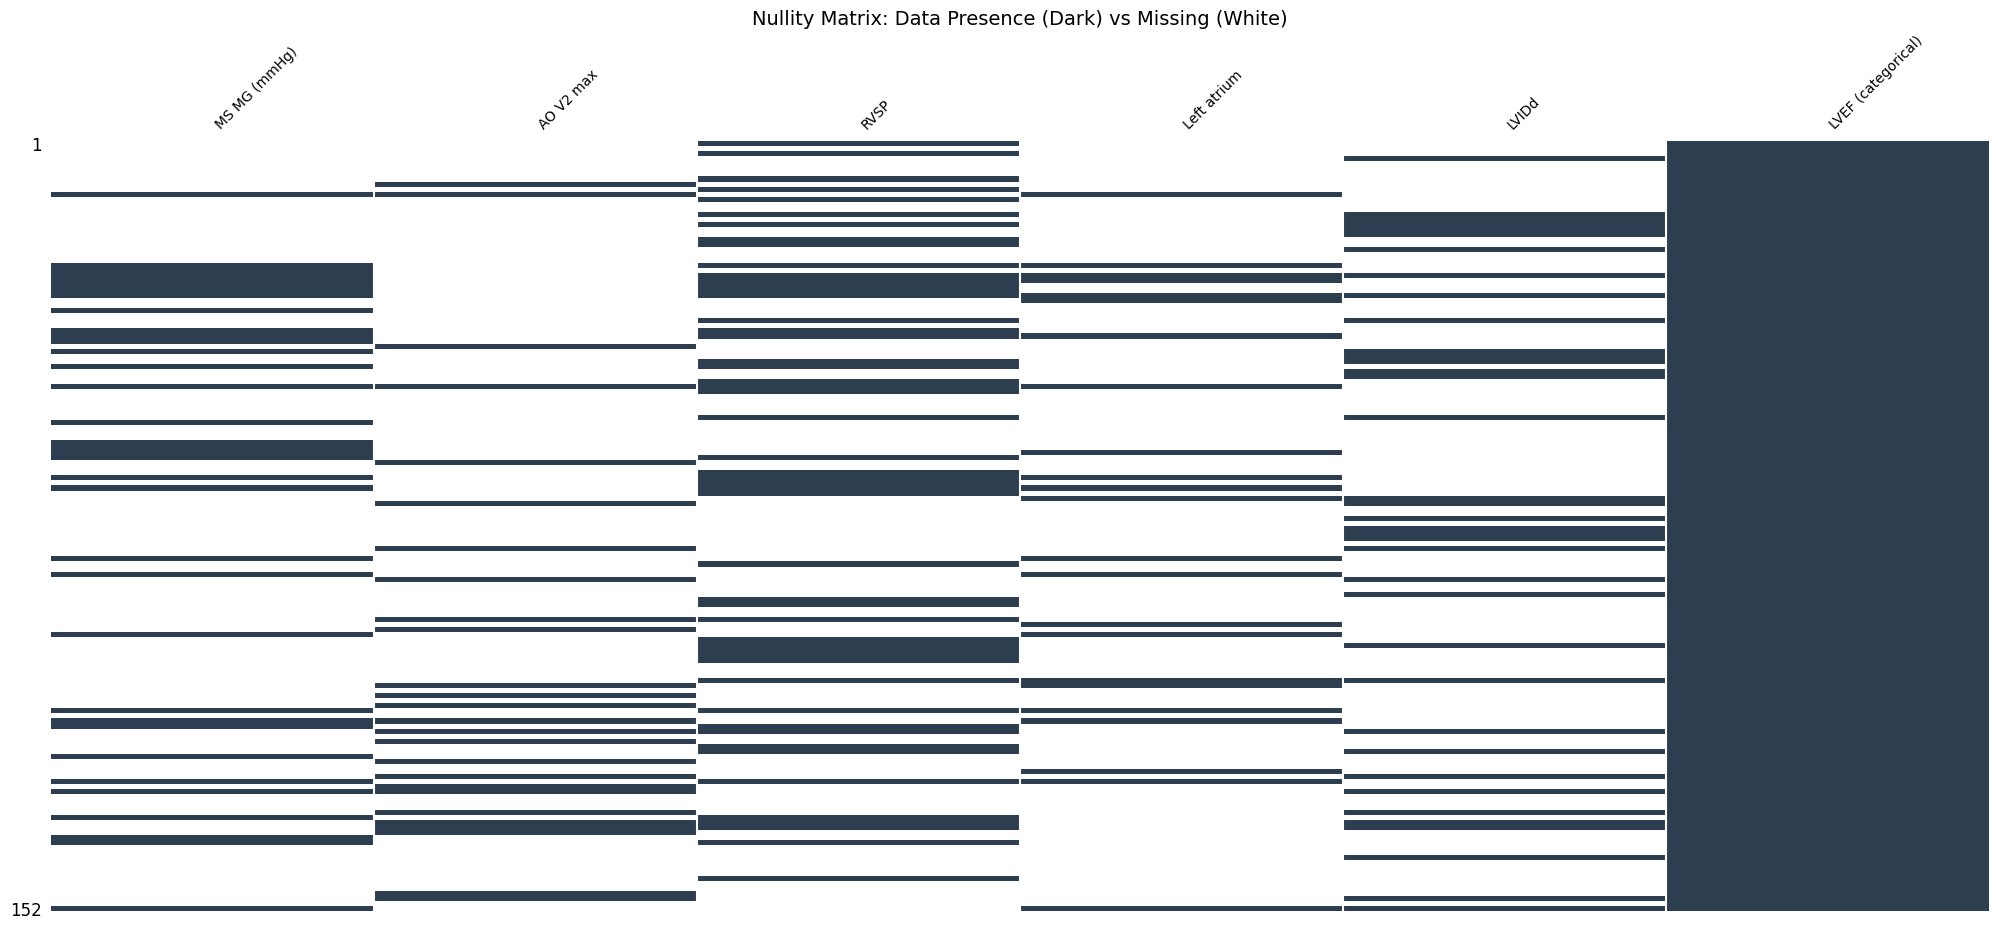

Note: Correlation of Missingness (1.0 = Always missing together):


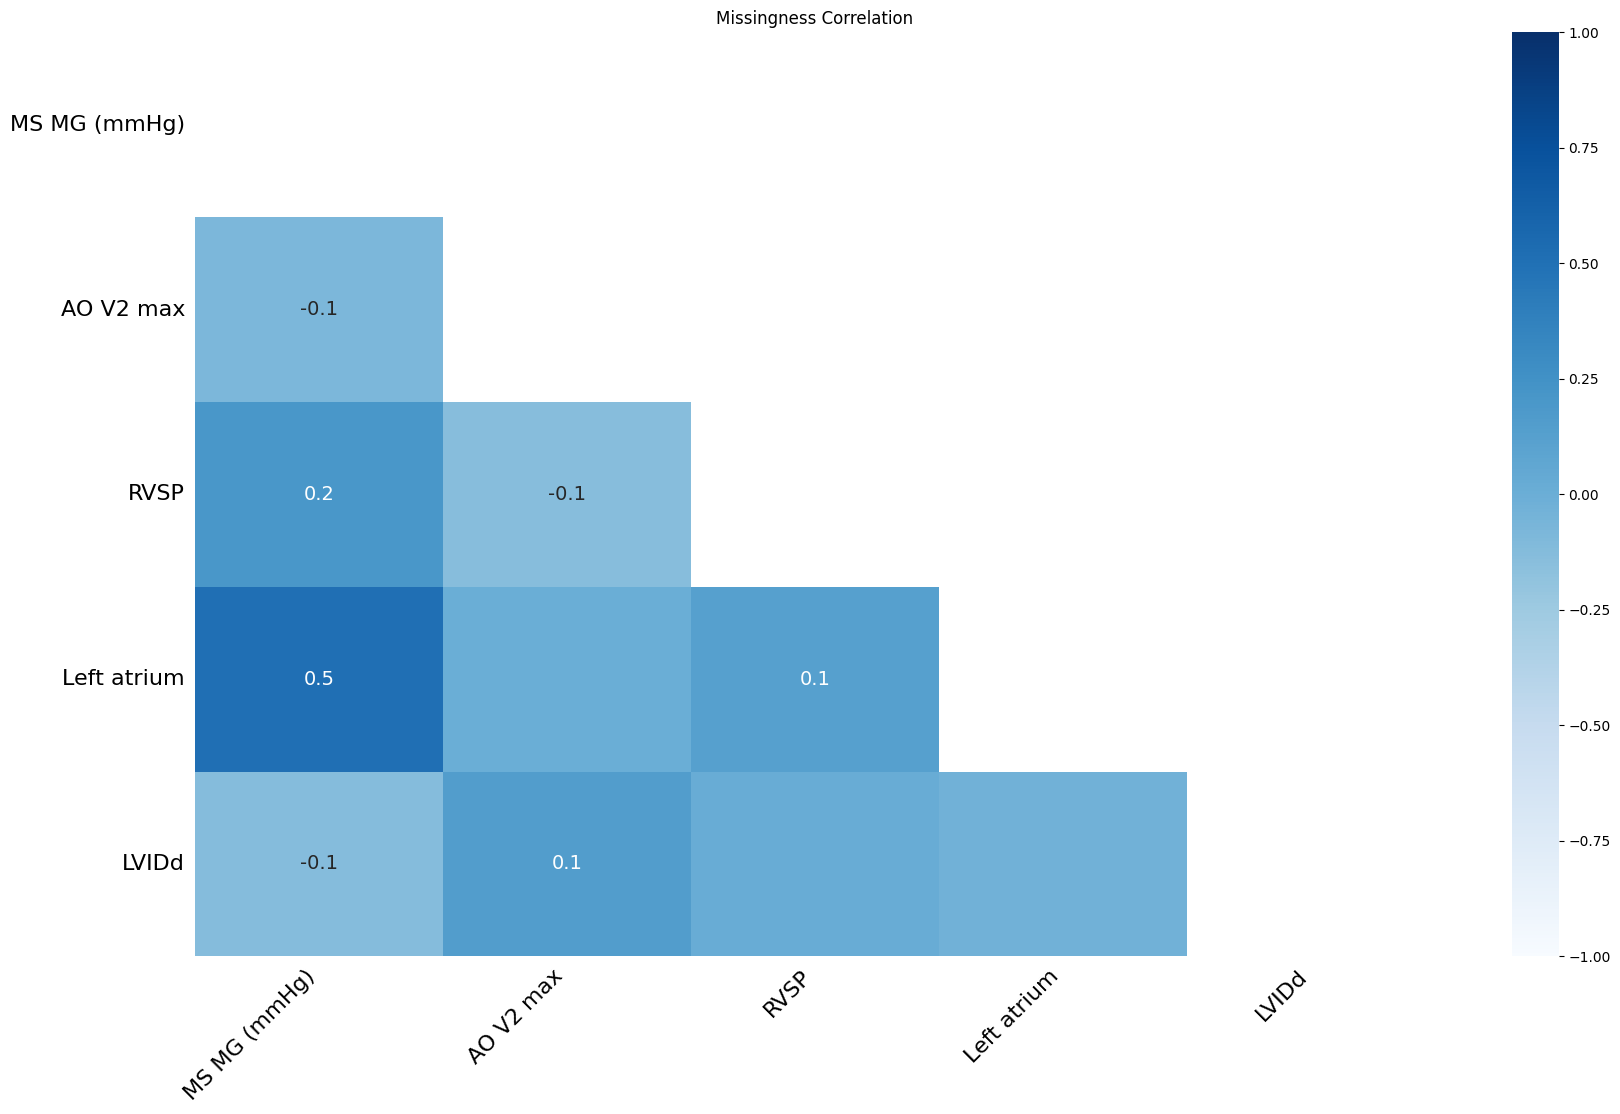

In [191]:
# Print missingness visuals
# We run echo_missingness first to feed its data to the patient_nullity method
extractor_execute = extractor.transform()
missingness_matrix = auditor.echo_missingness() 

viz.patient_nullity()

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #eff9ff; color: #003152;">
    <strong style="font-size: 1.2em;">Visual audit: Proving the "Clinical Silence"</strong> 
    <p>We used a two-pronged visual audit to map the "footprint" of the team's workflow
    </p>
    <p><strong>The nullity matrix:</strong> This shows a high-level view of data presence (blue) versus absence (white).</p>
    <ul>
        <li><strong>The striation pattern:</strong> The horizontal white gaps across other hemodynamic variables are not random. They represent patients where the clinician performed a visual assessment, determined the valves were "grossly normal," and intentionally skipped time-consuming quantitative measurements. This suggests data density follows a <strong>pathology-first</strong> logic.</li>
    </ul>
    <p><strong>The correlation heatmap:</strong> This quantifies how the absence of one measurement predicts the absence of another.</p>
    <ul>
        <li><strong>The Mitral-Atrial Cluster (r=0.5):</strong> The strongest correlation in the dataset. Mitral Stenosis (MS) physically causes Left Atrial enlargement. This $0.5$ correlation proves that clinicians work in "anatomical sets." If they identify a Mitral issue, they measure the associated chamber (LA). If the valve is healthy, they skip both.</li>
        <li><strong>RVSP as a triage variable (r=0.2):</strong> Pulmonary pressure (RVSP) shows low correlation with other missingness, confirming it is often attempted as a "standalone" marker of severity, regardless of which valve is being measured.</li>
    </ul>
</div>


Echocardiogram Triage Matrix notes:
----------------------------------------
A 'Hot' cell (High %) indicates a parameter the cardiologist deemed mandatory for triage.


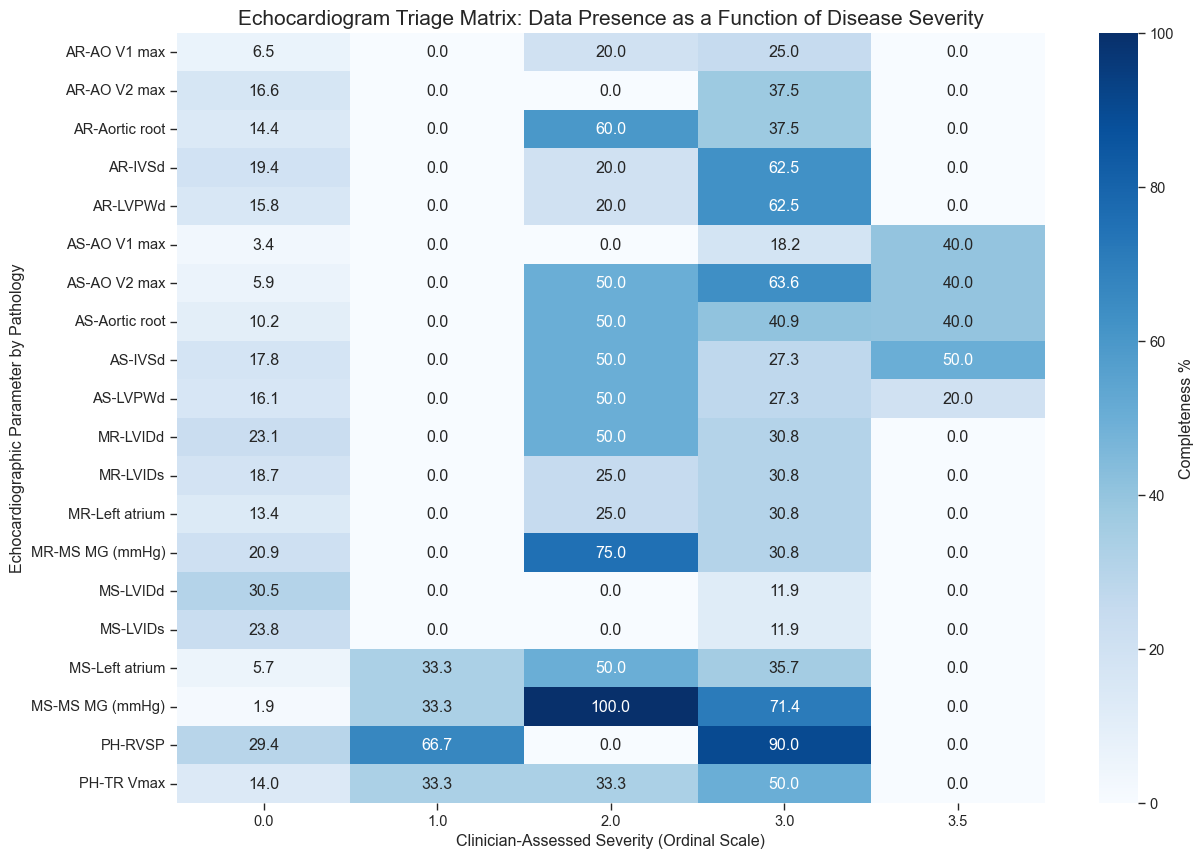

In [192]:
# Generate triage matrix
viz.echo_matrix(missingness_matrix)

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #eff9ff; color: #003152;">
    <strong style="font-size: 1.2em;">The Echocardiogram Triage Matrix: Data as a Function of Severity</strong> 
    <p>This heatmap illustrates the logic's core of the Brigade team. We plotted the Completeness % of specific echocardiographic parameters against the Clinician-Assessed Severity of the disease.</p>
    <p><strong>The "Severity-Driven Completeness" Trend:</strong> Notice the deep blue cells (high completeness) as we move toward the right side of the x-axis (Severity 2.0 to 3.5).</p>
    <ul>
        <li><strong>The finding:</strong> For Mitral Stenosis (MS), when severity is "Critical" (3.0), the completeness of the Mean Gradient (MG) jumps to 71.4%, and it hits 100% for Moderate cases.</li>
        <li><strong>The clinical reasoning:</strong> Clinicians do not measure what is healthy. They only perform time-consuming quantitative assessments when the initial visual "Quick Scan" suggests pathology. This is the definition of Missing Not At Random (MNAR).</li>
    </ul>
    <p><strong>The Pulmonary Hypertension signal:</strong> Look at the PH-RVSP row. At Severity 3.0, the data is 90.0% complete.</p>
    <ul>
        <li><strong>The finding:</strong> RVSP is almost always documented when the patient is severely ill, but only 29.4% documented when severity is 0.0 (None). This confirms that RVSP is a "high-stakes" variable used specifically to validate surgical candidates.</li>
    </ul>
    <p><strong>The "Normal Silence" (Severity 0.0):</strong> The left-most column (Severity 0.0) is almost entirely pale blue, with completeness often below 10%.</p>
    <ul>
        <li><strong>The finding:</strong> This pattern provides the ultimate justification for our Natural Normal Imputation. It proves that these nulls are not "missing values"—they are confirmed normal findings that the clinicians simply did not have the time to document.</li>
    </ul>
    <p><strong>Conclusion:</strong> Standard medical statistics and research approaches suggest dropping missing values or using simple averages. However, this matrix proves that doing so would delete 90% of our "Healthy" cohort and bias the model toward the sickest patients. By quantifying the link between Pathology and Documentation, we turn a "data quality issue" into a feature of the clinical workflow.</p>
</div>

### ⚙️ Feature engineering (Extractor and calculator)
---

**String parsing using Regex**

The raw data for medications and diagnoses consists of free-text strings (e.g., "Carvedilol 6.25mg bid, Enalapril 10mg qd"). To make this machine-readable, we use a custom Regex Engine defined in our `ClinicalConfig`.

* **Logic:** The engine splits the strings, identifies the drug class, extracts the numeric dosage, and maps the frequency (e.g., bid $\rightarrow$ 2) to calculate the Total Daily Dose.

**Clinical Flags: Phenotyping the Patient**

Beyond continuous scores, we generate binary "Clinical Flags" to assist in triage:

* `Mixed_Mitral`: Triggered if both Stenosis and Regurgitation patterns are found in the same valve.

* `Complexity_Score`: A calculated heuristic that sums valvular involvements and high-weight medications.

* `Approach` **(Native, Percutaneous, Surgical):** Automatically categorizing patients based on their surgical history and current pathology to determine if they belong in the Phase 3.

In [193]:
# Showcase a row for a "before" table
# We set the 'ID' column as the Index, given these were stored in descending order
# The if/elif/else is here if you want to re-execute this cell's code with other case_id 
if 'ID' in df.columns:
    df.set_index('ID', inplace=True)
elif df.index.name == 'ID':
    print("ID is already set as the index. Proceeding...")
else:
    print("Error: 'ID' column not found in DataFrame!")

case_id = "66"
before = df.loc[[case_id], ['Pre-procedure diagnosis', 'Medications', 'RVSP']]
print("\nRaw dataset row (input)\n" + '-'*40)
display(before)

# The same row after the transform method has been applied
after = df.loc[[case_id], ['Anatomy_Pre', 'Medications','Approach', 'RAAS_Inhibitors_name', 'RAAS_Inhibitors_tdd']]
print("\nTransformed dataset row (output)\n" + '-'*40)
display(after)


Raw dataset row (input)
----------------------------------------


,Pre-procedure diagnosis,Medications,RVSP
ID,,,
66,"Severe aortic stenosis, Severe mitral stenosis",Warfarin 5 mg QD | Enalapril 10 mg BID,NaN



Transformed dataset row (output)
----------------------------------------


,Anatomy_Pre,Medications,Approach,RAAS_Inhibitors_name,RAAS_Inhibitors_tdd
ID,,,,,
66,"Aortic stenosis, Mitral stenosis",Warfarin 5 mg QD | Enalapril 10 mg BID,Surgical,Enalapril,20.0


**Strategic Feature Selection: Anchoring the Model**

Following our audit, we curated a subset of "High-Impact" variables. Rather than using all available data, we selected these anchors based on their clinical signal and their ability to withstand our "Natural Normal" imputation:

| Variable | Role in Analysis | Reason for selection |
| :- | :- | :- |
| **MS MG** | Primary Functional (Mitral) | Strongest MNAR signal ($1.9\% \rightarrow 100\%$ capture). Essential for quantifying Mitral Stenosis burden. |
| **AO V2 max** | Primary Functional (Aortic) | Key hemodynamic marker for Aortic Stenosis severity and primary surgical decision-making. |
| **RVSP** | Hemodynamic Anchor | Important for secondary disease burden (Pulmonary Hypertension). High capture ($90\%$) in severe cases. |
| **Left atrium** | Primary Remodeling | Despite lower overall capture, LA size serves as the "long-term memory" of mitral disease and volume overload. |
| **LVIDd** | Geometric Anchor | Necessary for identifying the "Remodeling Paradox," specifically for chronic Regurgitation (MR/AR) cases. |

In [194]:
# Clinical Baseline & Prevalence
# ==========================================
extractor.baseline()
extractor.disease_profiler()

print(f"\nDisease prevalence: (n={len(df)})\n" + '-'*40)
prevalence = extractor.diagnoses_prevalence()
display(prevalence.head(10))

print("\nDisease complexity\n" + '-'*40)
for key, value in extractor.complexity_stats.items():
    print(f"{key}:  {value}")

Baseline characteristics
----------------------------------------


,Value,Completeness,Type
Characteristic,,,
Age,47.1 ± 15.7,100.0%,Continuous
Gender,Mode: Female (64.5%),100.0%,Categorical
Weight,71.6 ± 16.2,98.0%,Continuous
OSat,94.9 ± 9.6,99.3%,Continuous
SBP R,124.6 ± 18.7,100.0%,Continuous
DBP R,76.7 ± 12.5,100.0%,Continuous
Heart rate,76.6 ± 14.1,100.0%,Continuous



Disease prevalence: (n=152)
----------------------------------------


,Patient Count,Prevalence (%)
Diagnosis,,
Mitral stenosis,49,32.2
Aortic stenosis,34,22.4
Secundum atrial septal defect,22,14.5
Mitral regurgitation,19,12.5
Pulmonary hypertension,15,9.9
Aortic regurgitation,15,9.9
Surgical aortic valve replacement,14,9.2
Bicuspid aortic valve,12,7.9
Mitral valve percutaneous valvuloplasty,11,7.2



Disease complexity
----------------------------------------
Total Patients:  152
Mixed Mitral:  7
Mixed Aortic:  1
Multi-Valvular:  8
Significant PH (>=2.0):  13
AFib Present:  7



Complexity frequency and stratification
----------------------------------------


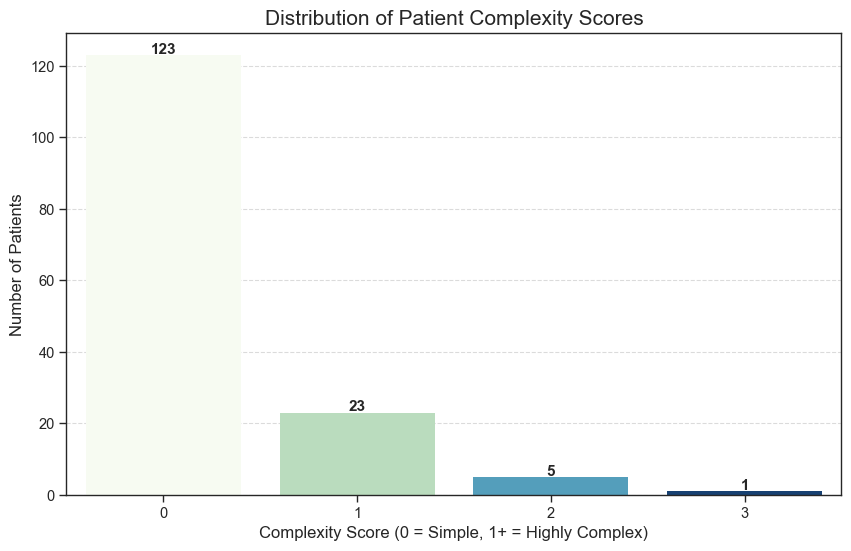

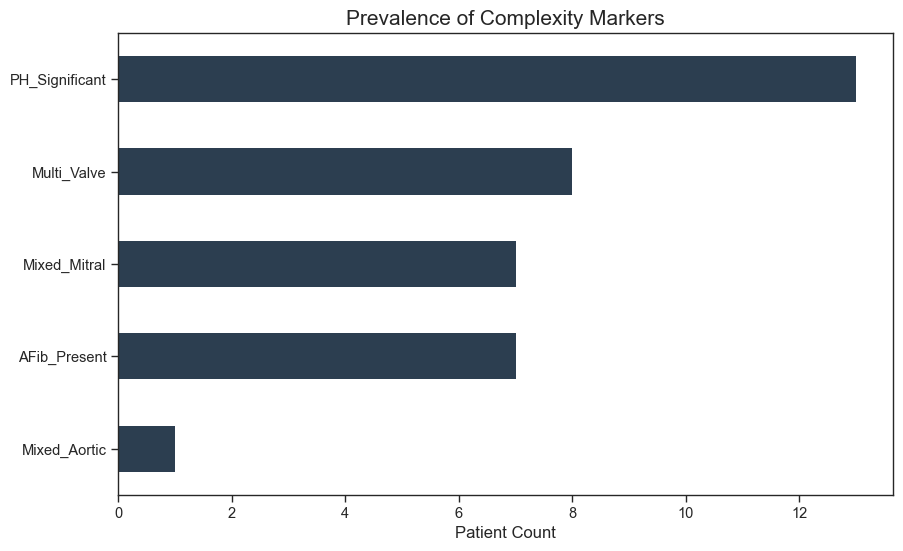

In [195]:
# Complexity Analysis
viz = Visualizer(df, config)
stats.df = df

print("\nComplexity frequency and stratification\n" + '-'*40)
viz.complexity_frequency()
viz.complexity_markers()

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #eff9ff; color: #003152;">
    <strong style="font-size: 1.2em;">Clinical Cohort Profile</strong> 
    <p><strong>Disease Prevalence: </strong>The Structural Burden</p>
    <ul>
        <li><strong>Rheumatic/Structural Dominance:</strong> Mitral Stenosis (32.2%) and Aortic Stenosis (22.4%) are the primary drivers of the cohort.</li>
        <li><strong>Surgical history:</strong> Nearly 10% of the patients (9.2%) presented with a pre-existing surgical aortic valve replacement, indicating that the brigade is managing a mix of new cases and complex long-term follow-ups.</li>
    </ul>
    <p><strong>Disease complexity: </strong>The high stakes</p>
    <ul>
        <li><strong>Multi-Valvular Involvement:</strong> We identified 8 patients with multi-valvular disease and 7 with Mixed Mitral pathology (Stenosis + Regurgitation).</li>
        <li><strong>Pulmonary Hypertension (PH):</strong> 13 patients presented with Significant PH (moderate or worse), a critical indicator of late-stage disease and surgical risk.</li>
    </ul>
</div>

Echo parameters heatmap interaction
----------------------------------------


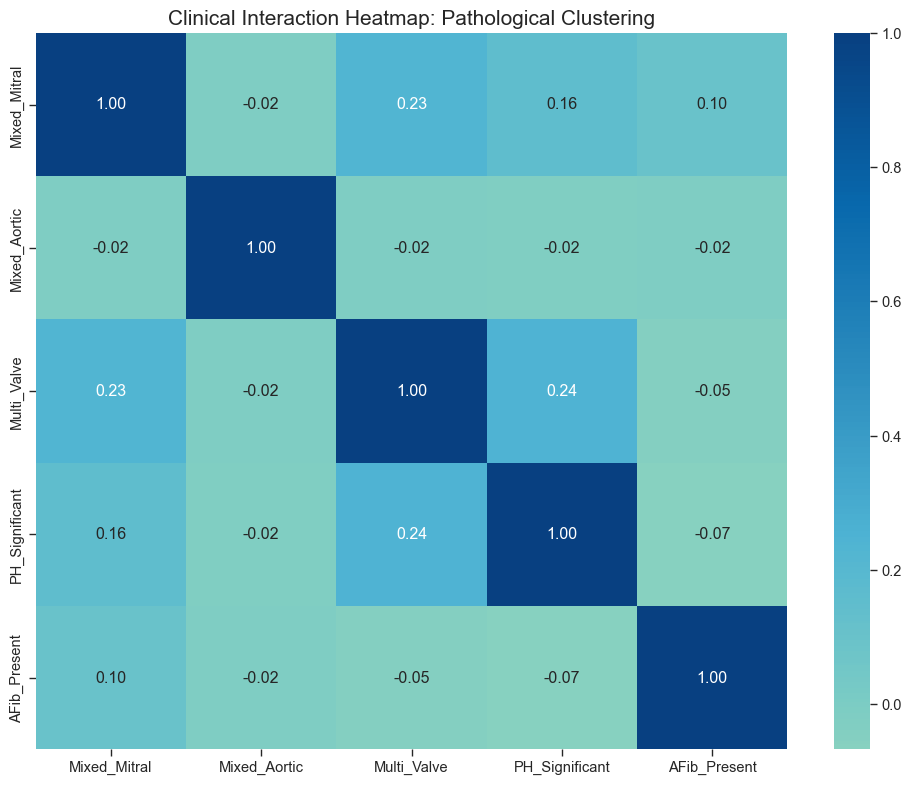

In [196]:
# Generate heatmap interaction for our desired echo parameters
print("Echo parameters heatmap interaction\n" + '-'*40)
viz.complexity_heatmap()

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #eff9ff; color: #003152;">
    <strong style="font-size: 1.2em;">Clinical interaction heatmap</strong> 
    <p>This heatmap visualizes the interaction between our engineered "Clinical Flags." Rather than looking at raw measurements, we are looking at the coexistence of high-complexity disease states.</p>
    <p><strong>The "Congestive Complex" (Multi-valvular disease and pulmonar hypertension): </strong>We observe a positive interaction (0.24) between multi-valvular disease involvement and significant pulmonary hypertension (defined as moderate or worse).</p>
    <ul>
        <li><strong>Clinical insight:</strong> This statistical link points out the physiological progression of valvular disease. Patients with multiple diseased valves often develop secondary Pulmonary Hypertension due to chronic volume and pressure overload.</li>
    </ul>
    <p><strong>Mitral complexity and secondary effects: </strong>There is a positive interaction (0.23) between mixed Mitral valve disease (stenosis + regurgitation) and Multi-valvular disease.</p>
    <ul>
        <li><strong>Clinical insight:</strong> Patients with complex mitral presentations are statistically more likely to have concomitant Aortic or Tricuspid pathology.</li>
    </ul>
    <p><strong>The "independece" of Aortic cases: </strong>Mixed aortic valve disease shows almost zero or slightly negative correlations with other pathologies (around -0.02).</p>
    <ul>
        <li><strong>Clinical insight:</strong> In the 2025 cohort, complex Aortic presentations appear to be more "isolated" than Mitral cases. This suggests a different patient phenotype—potentially older patients with degenerative calcific disease</li>
    </ul>
    <p>This interaction analysis proves that our feature engineering isn't just creating labels; it's capturing <strong>clinical phenotypes.</strong></p>
</div>

**The Medication Burden Index (MBI)**

The centerpiece of our feature engineering is the Medication Burden Index. This score quantifies how aggressively a patient is being medically managed, which serves as a proxy for both physiological severity and care complexity.

For a detailed breakdown of the weighting logic and scoring math, see the [Medication Burden Index (MBI)](../README.md#the-medication-burden-index-mbi) section in the project documentation.

In [197]:
# MBI & Statistical Imputation
# ==========================================
stats.apply_imputation()
calculator_execute = calc.medication_index().head(5)

case_ids = ["66", "120", "55"]
mbi_rows = df.loc[df.index.isin(case_ids), ['Anatomy_Pre', 'Medications', 'MBI']]
print("\nMBI rows showcase\n" + '-'*40)
display(mbi_rows)

Handled MS MG (mmHg) using 'Natural Normal' distribution.
Handled AO V2 max using 'Natural Normal' distribution.
Handled RVSP using 'Natural Normal' distribution.
Handled LVIDd using 'Natural Normal' distribution.

MBI rows showcase
----------------------------------------


,Anatomy_Pre,Medications,MBI
ID,,,
120,"Pulmonary hypertension, Mitral stenosis",Warfarin 2.5 mg QD | Furosemide 40 mg BID | Ca...,4.75
66,"Aortic stenosis, Mitral stenosis",Warfarin 5 mg QD | Enalapril 10 mg BID,2.00
55,"Atrial fibrillation, Mitral stenosis, Mitral r...",Amlodipine 10 mg QD | Bisoprolol 5 mg QD | Spi...,6.25


### ☑️ Imputation and its statistical validation
---

For a deep dive into the statistical justification used here, see the [Imputation to restore physiologic variance](../README.md#imputation-to-restore-physiologic-variance) section in the project documentation.

Before performing high-level analytics, we must ensure our "Natural Normal" strategy didn't dilute the clinical signal. We execute `sensitivity_grid()` to visualize the distribution of the data before and after the injection of Gaussian noise.

We plot **measured** (grey) vs. **imputed** (blue) to visually compare the distributions before and after the injection of Gaussian noise.

Sensitivity analysis for the Stochastic Imputation
----------------------------------------


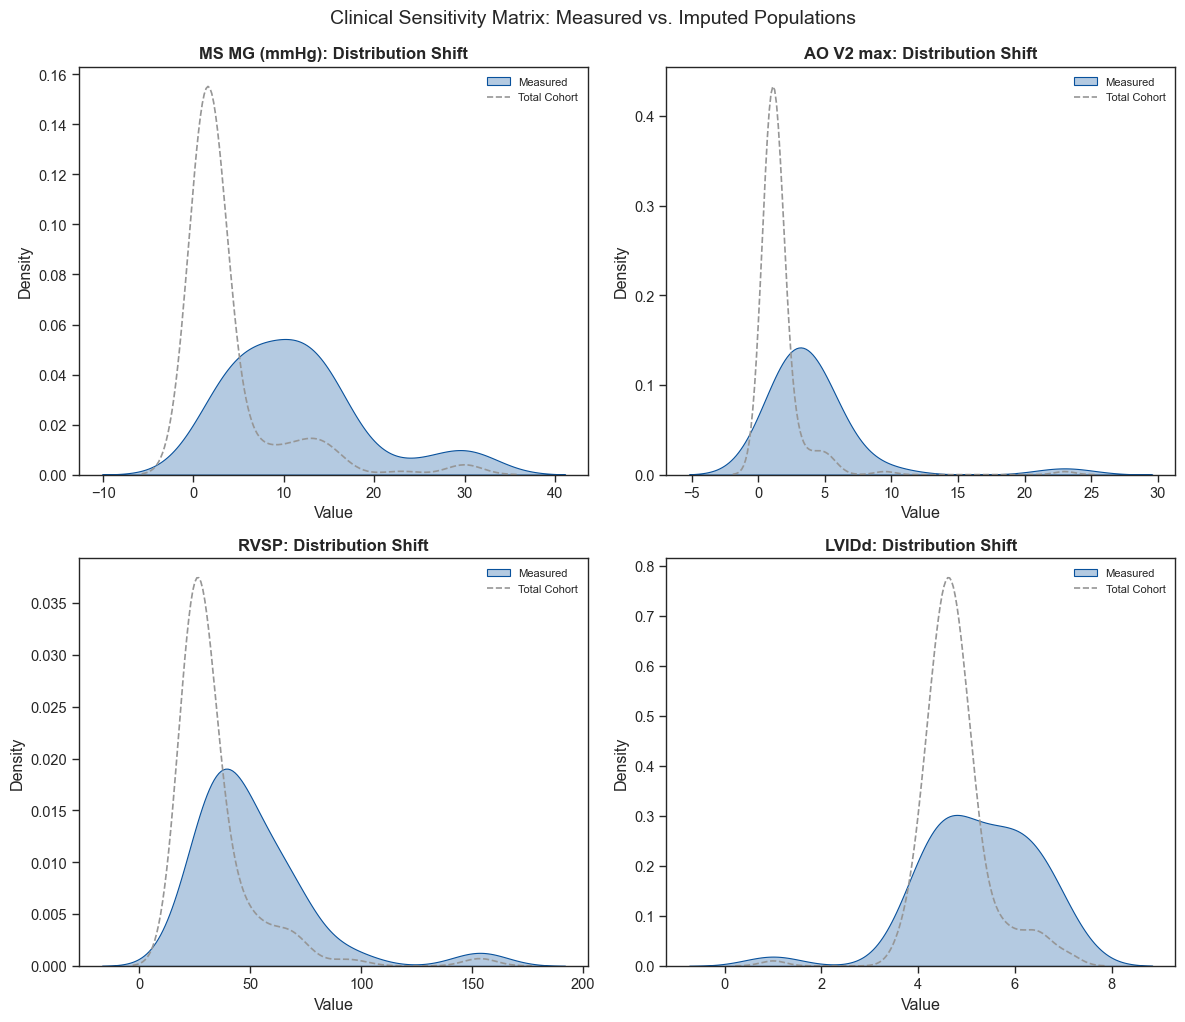

,Measured Mean,Imputed Mean,Delta (Shift),Triage Bias
Clinical Parameter,,,,
MS MG (mmHg),11.4,3.8,-7.6,Significant Shift
AO V2 max,4.3,1.6,-2.6,Significant Shift
RVSP,51.0,34.1,-16.9,Significant Shift
LVIDd,5.2,4.8,-0.5,Stable


In [198]:
# Visualizing imputation of Data and MBI validity
# ==========================================

# Sensitivity analysis
print("Sensitivity analysis for the Stochastic Imputation\n" + '-'*40)
viz.sensitivity_grid()
sensitivity_table = stats.sensitivity_report()
display(sensitivity_table)

<div style="padding: 15px; border: 1px solid #003152; border-radius: 5px; background-color: #eff9ff; color: #003152;">
    <strong style="font-size: 1.2em;">Sensitivity analysis and signal preservation</strong> 
    <p>The output above confirms that our <strong>Natural Normal Imputation</strong> successfully restored the clinical baseline for the 2025 cohort. By comparing the Measured distribution (patients with documented disease) against the Total Cohort (Measured + Imputed), we can draw three critical conclusions:</p>
    <ul>
        <li><strong>Pathological signal integrity:</strong> In the density plots the "grey" pathological peaks remain distinct and unshifted. This proves that our imputation did not "wash out" the sickest patients; we simply filled the "Clinical Silence" around them.</li>
        <li><strong>Quantifying the Triage Bias:</strong>  The table reveals a Significant Shift in means for hemodynamic variables, such as RVSP dropping from 51.0 mmHg (measured) to 33.8 mmHg (cohort). This delta is the mathematical proof of a <strong>High-Severity Documentation Threshold</strong>. It confirms that clinicians only performed time-intensive quantitative measurements when a preliminary "Quick Scan" indicated significant pathology—leaving the healthy portion of the population "silent" but present.</li>
    </ul>
</div>